# Model Selection: Cross‑Validation, Hyperparameter Tuning & Model Comparison

**Author:** Phabel Antonio López Delgado, BSc.

This notebook provides a comprehensive guide to model selection in supervised learning. It covers:

- **Data Preprocessing** – scaling and handling missing values (if any).
- **Cross‑Validation** – using k‑fold CV to estimate model performance robustly.
- **Hyperparameter Tuning** – using GridSearchCV to find optimal parameters for multiple algorithms.
- **Model Comparison** – evaluating Logistic Regression, Decision Tree, Random Forest, and SVM on the same dataset.
- **Visualisation** – interactive confusion matrices, feature importance, and learning curves.
- **Final Model Selection** – choosing the best model based on cross‑validation scores and test set performance.

**Key Techniques & Libraries:**
- `pandas`, `numpy` – data manipulation
- `sklearn.model_selection` – train_test_split, KFold, cross_val_score, GridSearchCV, learning_curve
- `sklearn.preprocessing.StandardScaler` – feature scaling
- `sklearn.linear_model.LogisticRegression` – linear classifier
- `sklearn.tree.DecisionTreeClassifier` – tree‑based classifier
- `sklearn.ensemble.RandomForestClassifier` – ensemble classifier
- `sklearn.svm.SVC` – support vector classifier
- `sklearn.metrics` – accuracy, F1‑score, classification report, confusion matrix
- `plotly`, `matplotlib`, `seaborn` – interactive and static visualisation

**Data Source:**
Pima Indians Diabetes Dataset – loaded from `https://gitlab.com/dgtic5/res/-/raw/main/aprendizajeSupervizado/Diabetes__Edited_.csv`. The dataset contains 768 samples, 8 features, and a binary target (0 = no diabetes, 1 = diabetes).

In [1]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# High-DPI for static plots
%config InlineBackend.figure_format = 'retina'

# Visualisation settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots directory exists
Path("plots").mkdir(exist_ok=True)

print("All imports successful.")

All imports successful.


In [2]:
# %% Data Loading
url = "https://gitlab.com/dgtic5/res/-/raw/main/aprendizajeSupervizado/Diabetes__Edited_.csv"
df = pd.read_csv(url)

# Rename columns for clarity (original columns are A, B, C, ...)
# Map to actual feature names:
# A = Pregnancies, B = Glucose, C = BloodPressure, D = SkinThickness,
# E = Insulin, F = BMI, G = DiabetesPedigreeFunction, H = Age, I = Outcome
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(y.value_counts())
print("\nSummary statistics:")
print(df.describe())

# Check for missing values (e.g., zeros in columns that shouldn't have zeros)
# For Pima dataset, some features have 0 values that are actually missing.
# We'll treat them as missing and impute (optional, but we'll keep simple for this demo).

Dataset shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Summary statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052

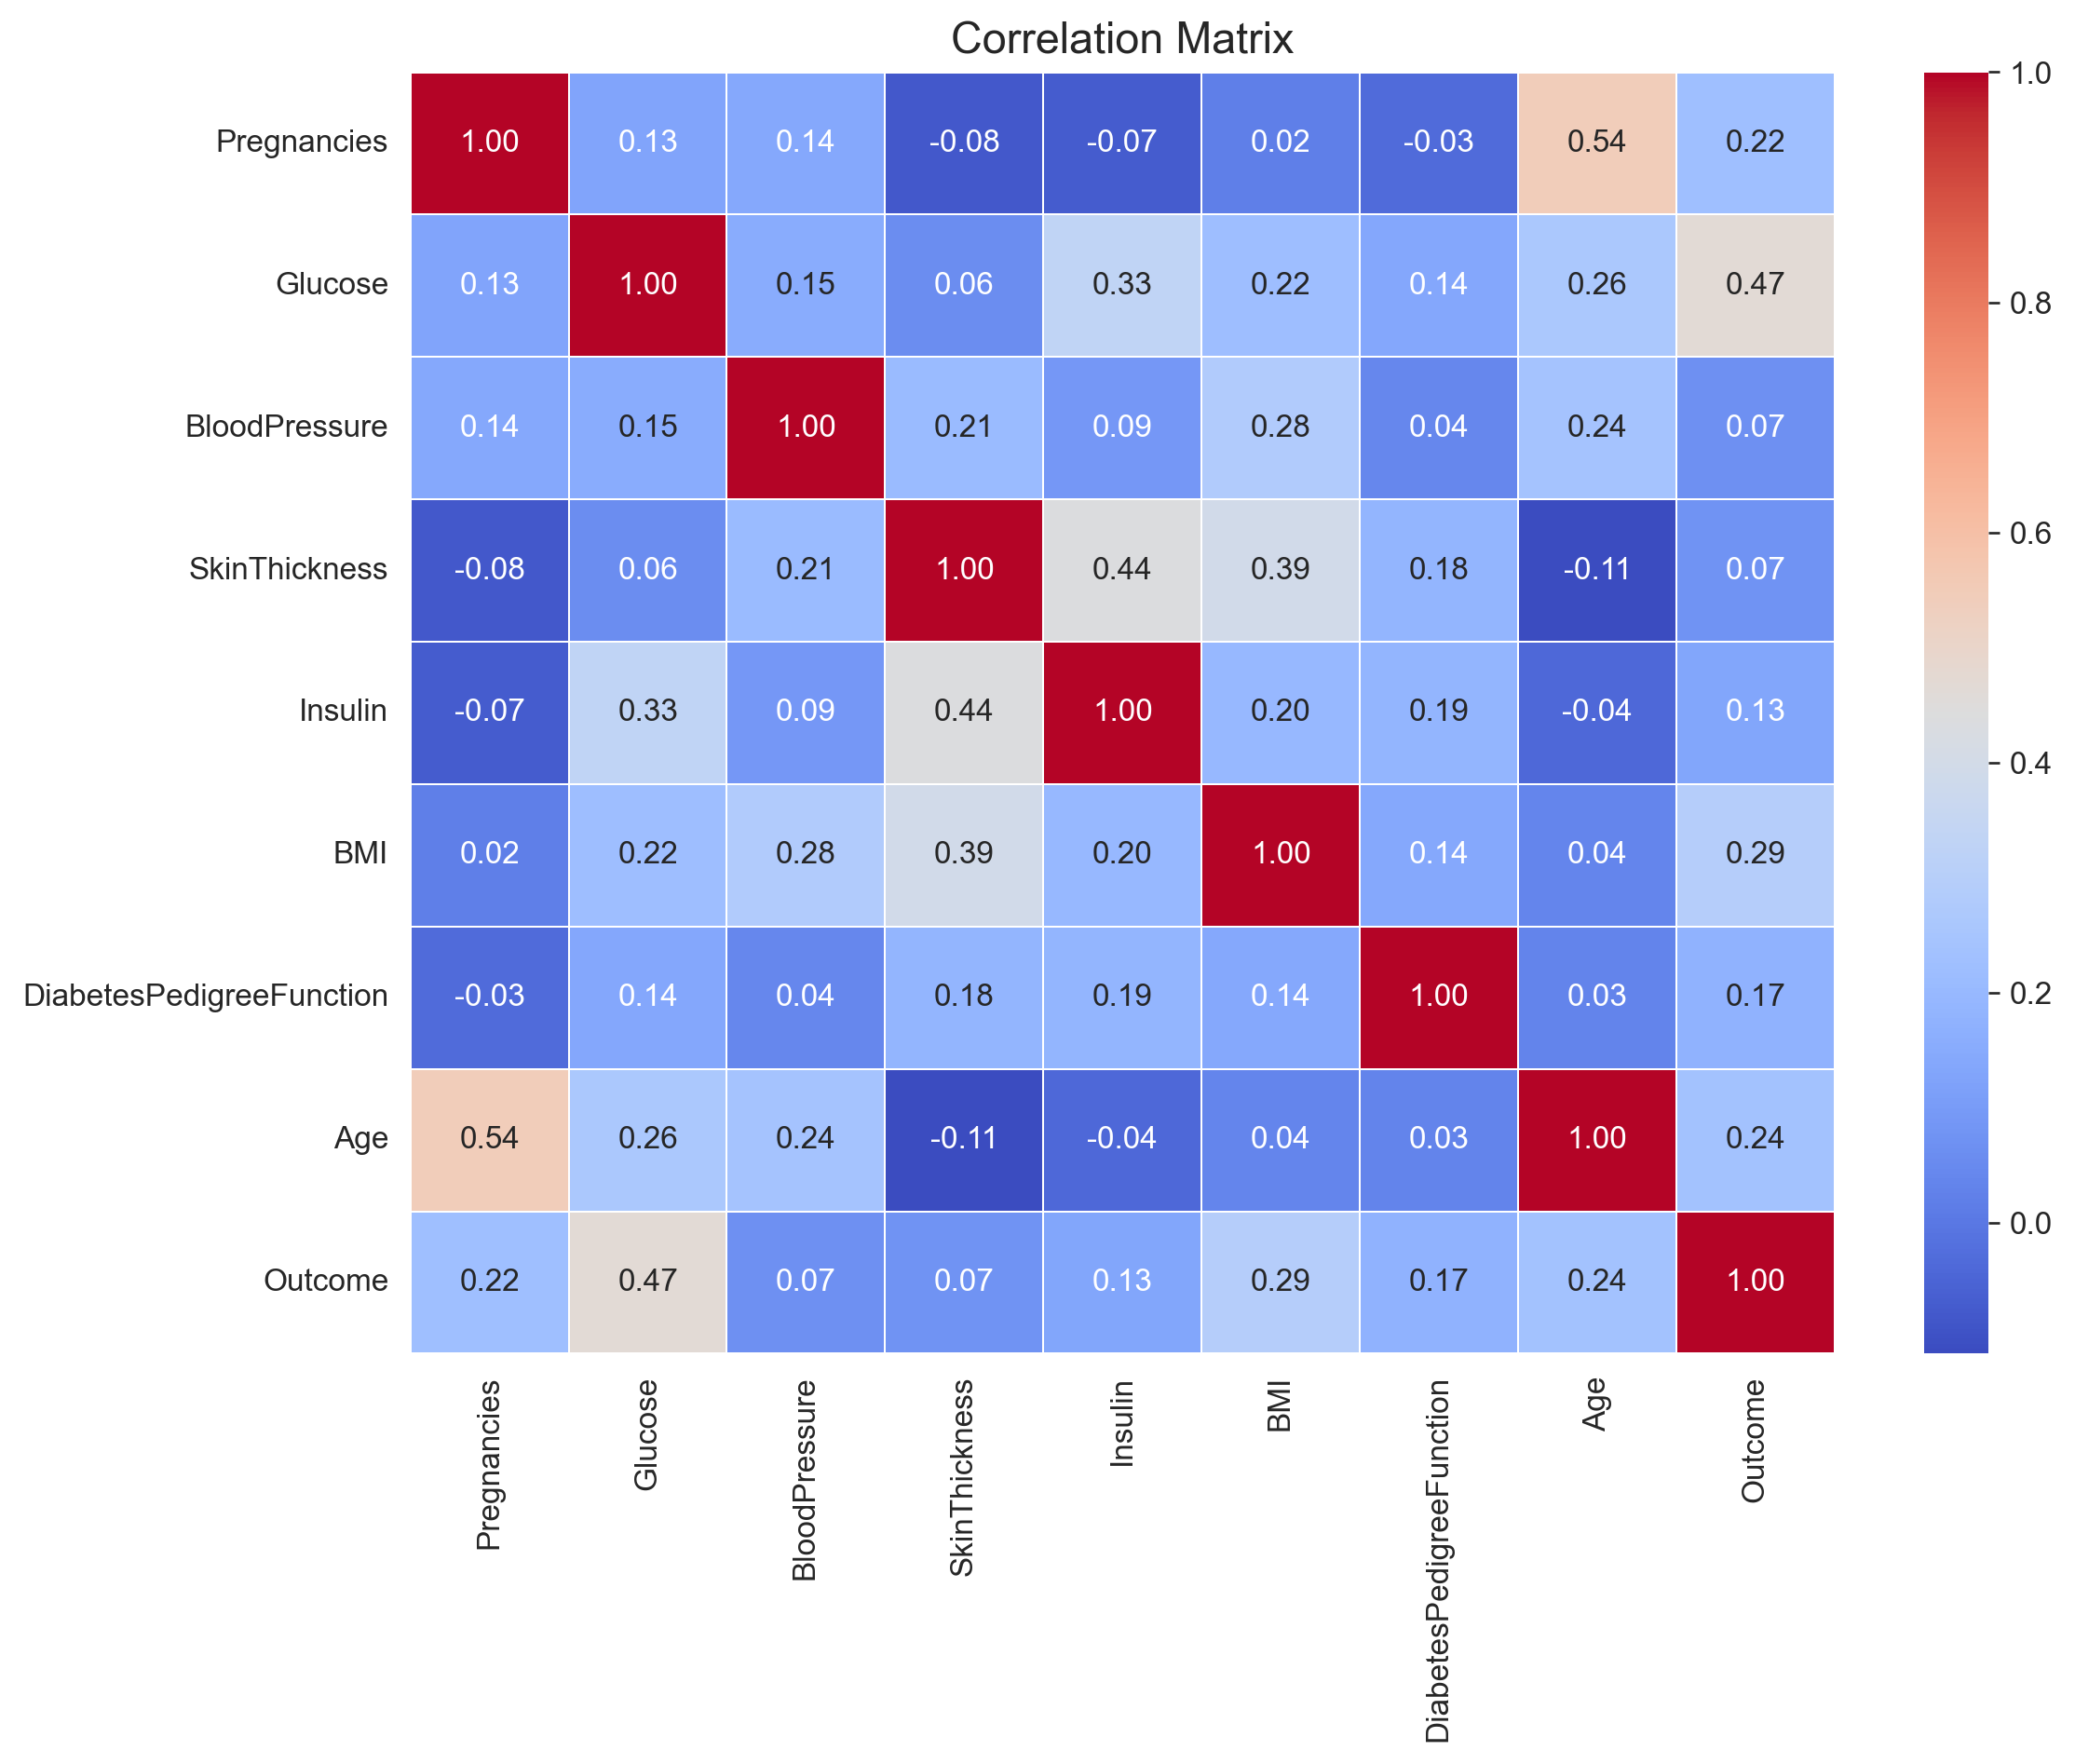

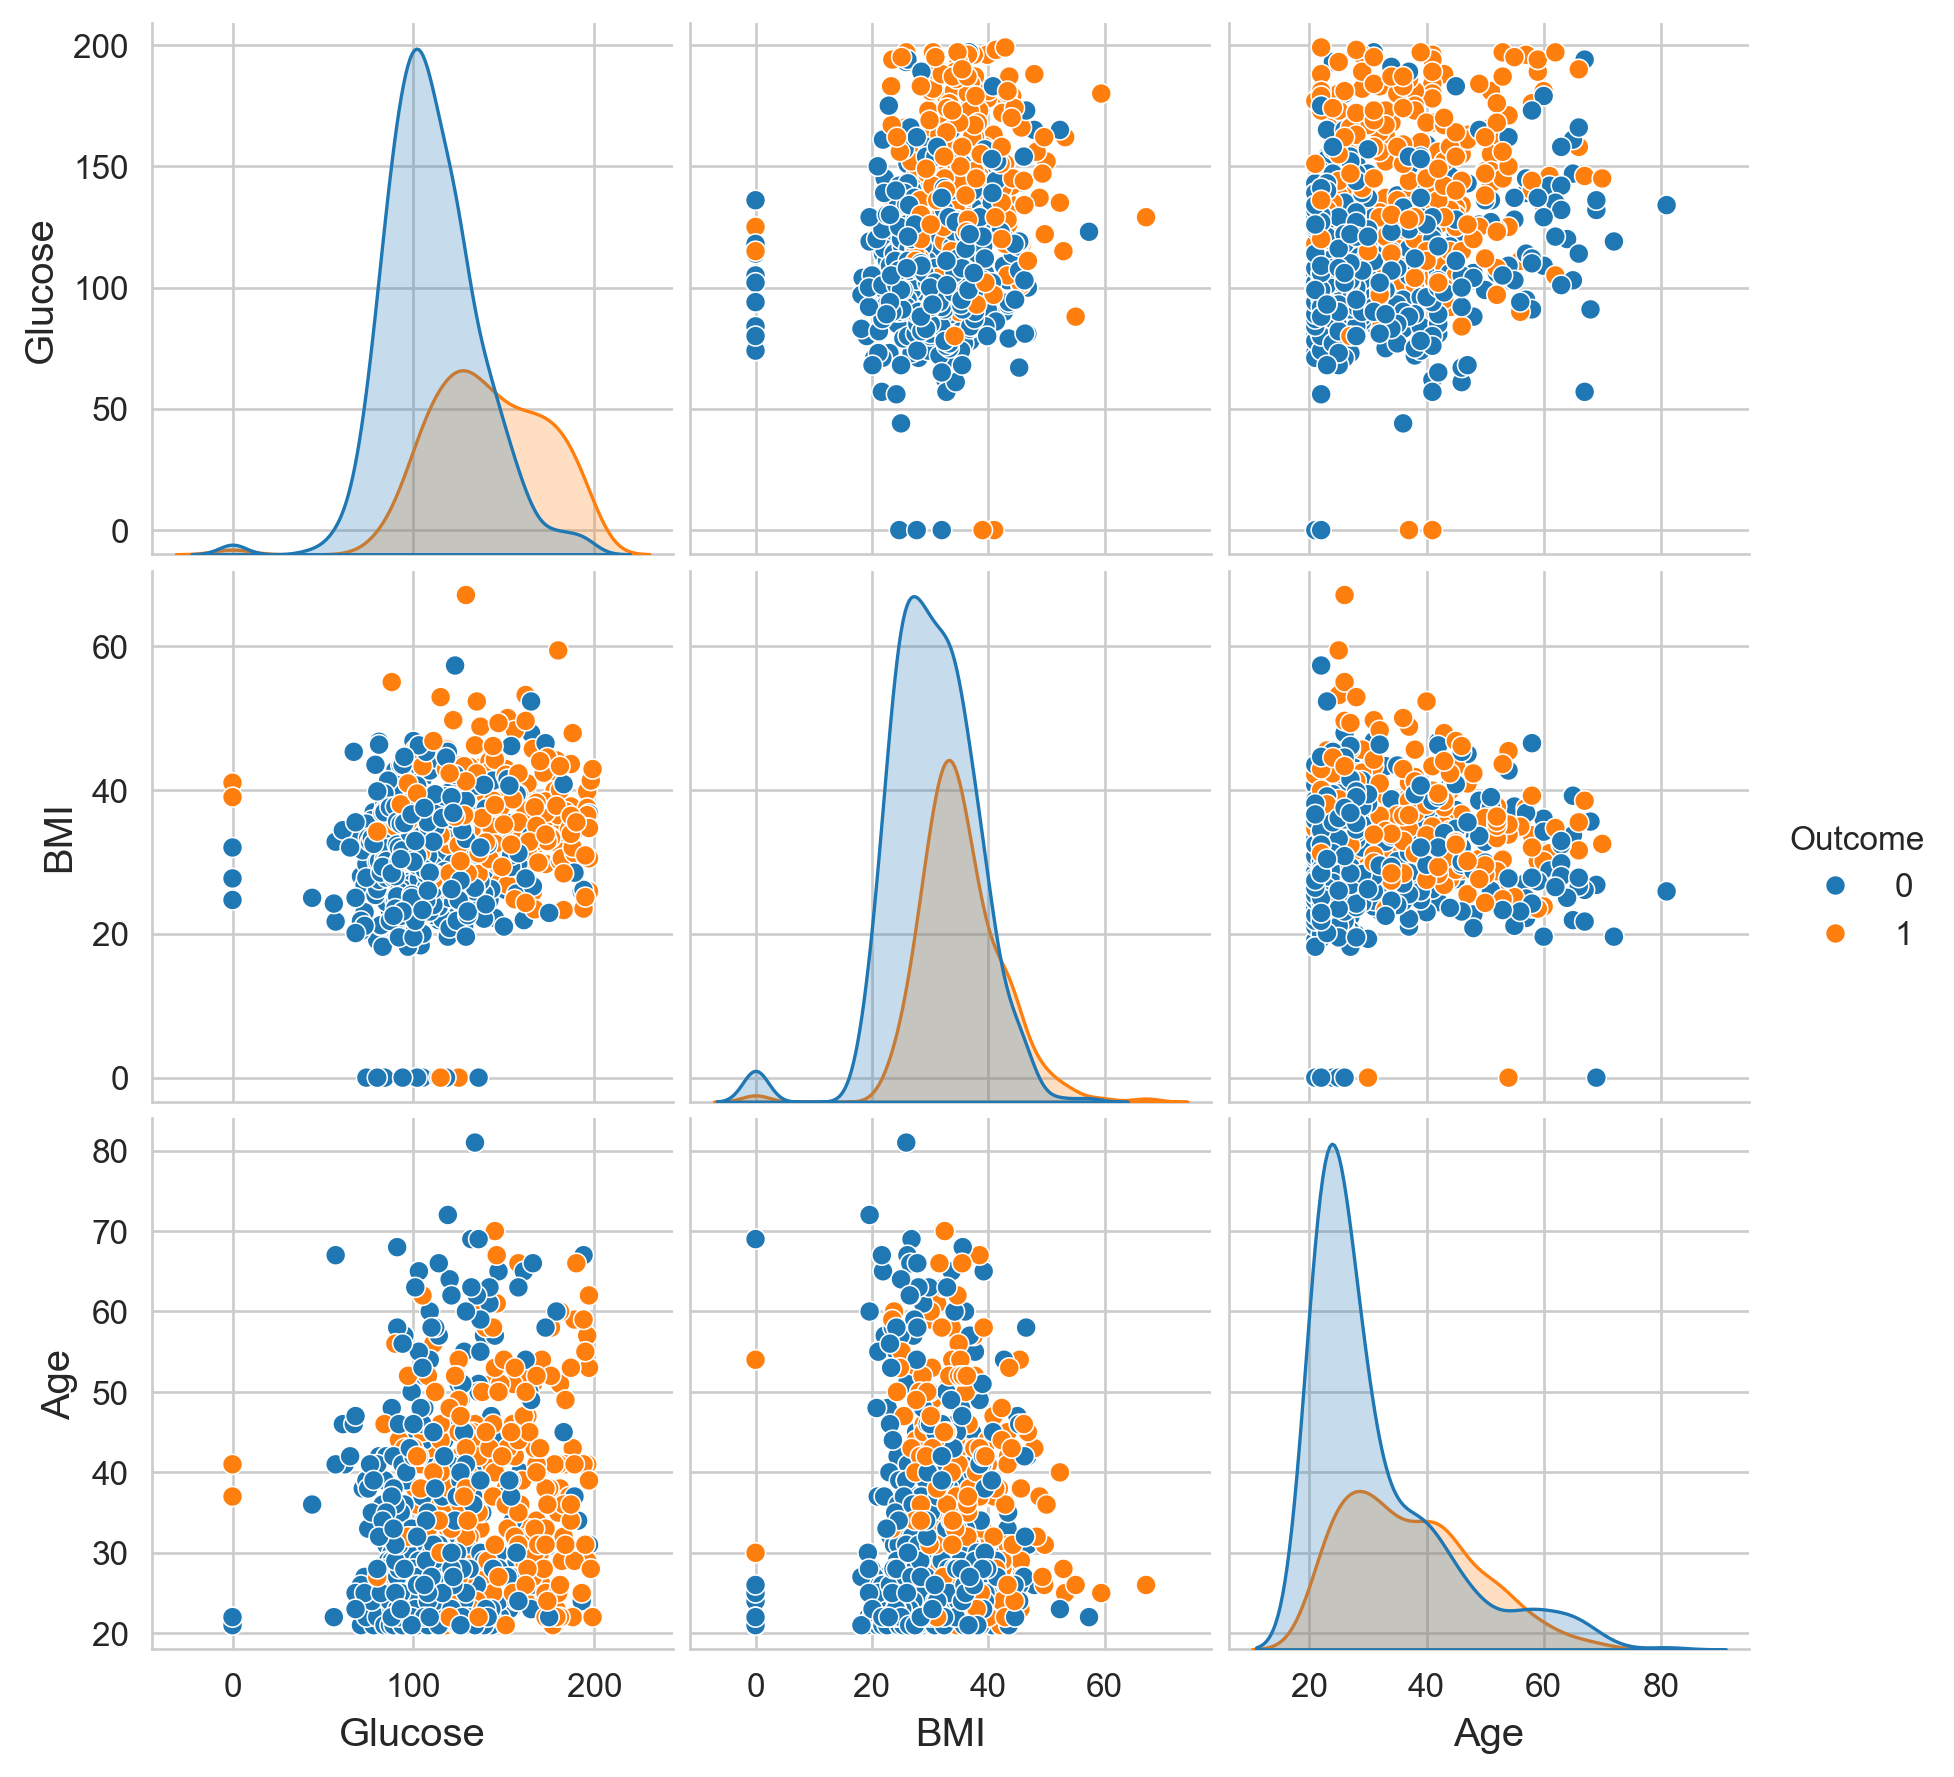

In [3]:
# %% Exploratory Data Analysis
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('plots/correlation_diabetes.png', dpi=300)
plt.show()

# Pair plot (only a subset for clarity)
features = ['Glucose', 'BMI', 'Age', 'Outcome']
sns.pairplot(df[features], hue='Outcome', diag_kind='kde')
plt.savefig('plots/pairplot_diabetes.png', dpi=300)
plt.show()

In [4]:
# %% Preprocessing
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train, validation, test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 537
Validation samples: 115
Testing samples: 116


## 1. Cross‑Validation: Base Models

We evaluate several classifiers using 5‑fold cross‑validation on the training set to get a baseline performance estimate.

In [6]:
# %% Cross-Validation Baseline
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name}: {scores.mean():.4f} (+-{scores.std():.4f})")

# Visualise cross-validation scores
df_cv = pd.DataFrame(cv_scores).T
fig = px.bar(
    df_cv,
    x=df_cv.index,
    y='mean',
    error_y='std',
    title='Cross‑Validation Accuracy (5‑fold)',
    labels={'index': 'Model', 'mean': 'Mean Accuracy'}
)
fig.update_layout(title_x=0.5, font=dict(size=14))
fig.show()

Logistic Regression: 0.7858 (+-0.0191)
Decision Tree: 0.6814 (+-0.0361)
Random Forest: 0.7450 (+-0.0189)
SVM: 0.7524 (+-0.0173)


## 2. Hyperparameter Tuning

We tune hyperparameters for each model using GridSearchCV on the training set (with 5‑fold CV) to find the best configuration.

In [7]:
# %% Grid Search for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)
print("Best params for Logistic Regression:")
print(grid_lr.best_params_)
best_lr = grid_lr.best_estimator_

# Grid Search for Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)
print("\nBest params for Decision Tree:")
print(grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

# Grid Search for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)
print("\nBest params for Random Forest:")
print(grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

# Grid Search for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf', 'poly', 'sigmoid']
}
grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_svm.fit(X_train, y_train)
print("\nBest params for SVM:")
print(grid_svm.best_params_)
best_svm = grid_svm.best_estimator_

Best params for Logistic Regression:
{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best params for Decision Tree:
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}

Best params for Random Forest:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 50}

Best params for SVM:
{'C': 100, 'gamma': 0.01, 'kernel': 'sigmoid'}


In [9]:
# %% Helper: Evaluate and Visualise
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"\n=== {model_name} ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1 (weighted): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    # Confusion matrix (Plotly)
    cm = confusion_matrix(y_test, y_pred)
    class_names = ['No Diabetes', 'Diabetes']
    fig = px.imshow(
        cm,
        text_auto=True,
        color_continuous_scale='Viridis',
        labels=dict(x='Predicted', y='True', color='Count'),
        title=f'{model_name} – Confusion Matrix',
        x=class_names, y=class_names
    )
    fig.update_layout(title_x=0.5, width=500, height=450)
    fig.show()
    # Static confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} – Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'plots/cm_{model_name.replace(" ", "_")}.png', dpi=300)
    plt.show()
    return acc, f1

## 3. Model Evaluation on Validation Set

We evaluate the tuned models on the validation set to compare their performance.


=== Logistic Regression ===
Test Accuracy: 0.7304
Test F1 (weighted): 0.7258

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.80        75
           1       0.63      0.55      0.59        40

    accuracy                           0.73       115
   macro avg       0.70      0.69      0.69       115
weighted avg       0.72      0.73      0.73       115



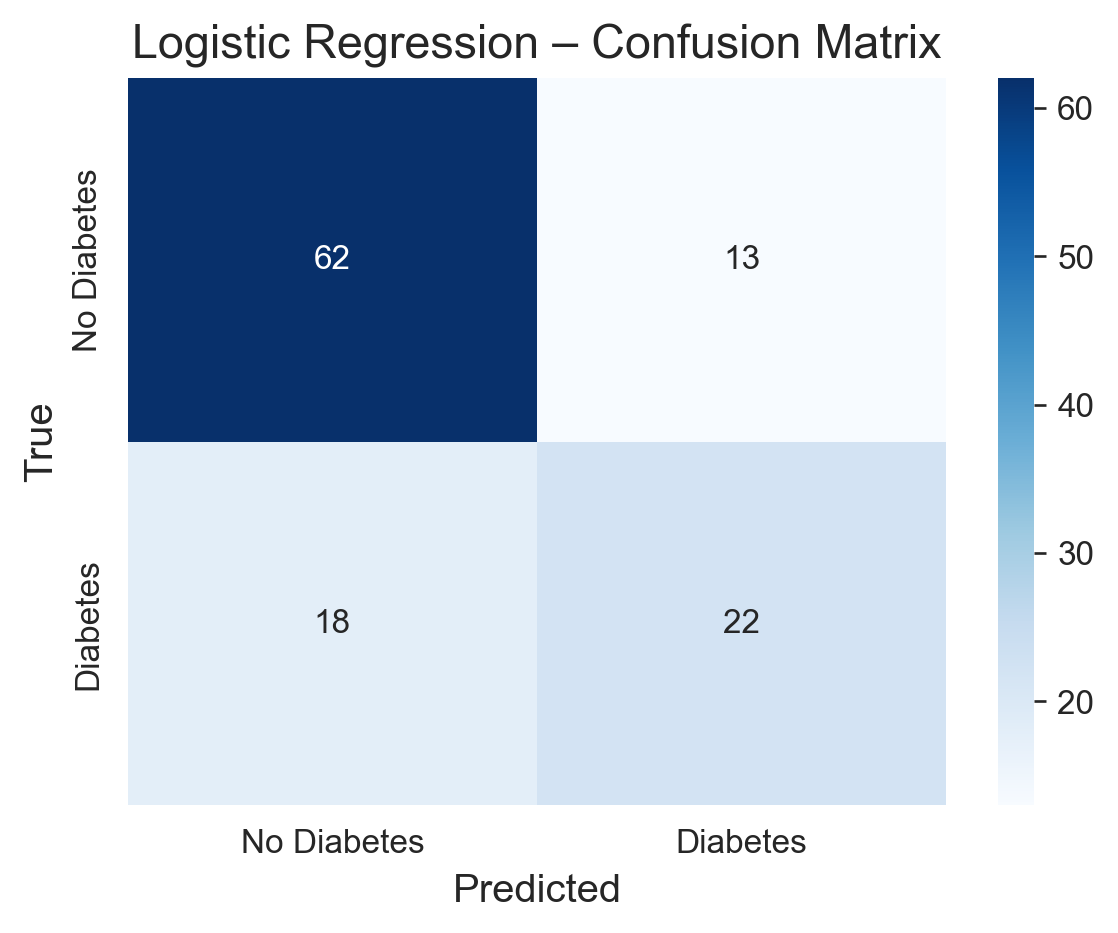


=== Decision Tree ===
Test Accuracy: 0.6957
Test F1 (weighted): 0.6947

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        75
           1       0.56      0.55      0.56        40

    accuracy                           0.70       115
   macro avg       0.66      0.66      0.66       115
weighted avg       0.69      0.70      0.69       115



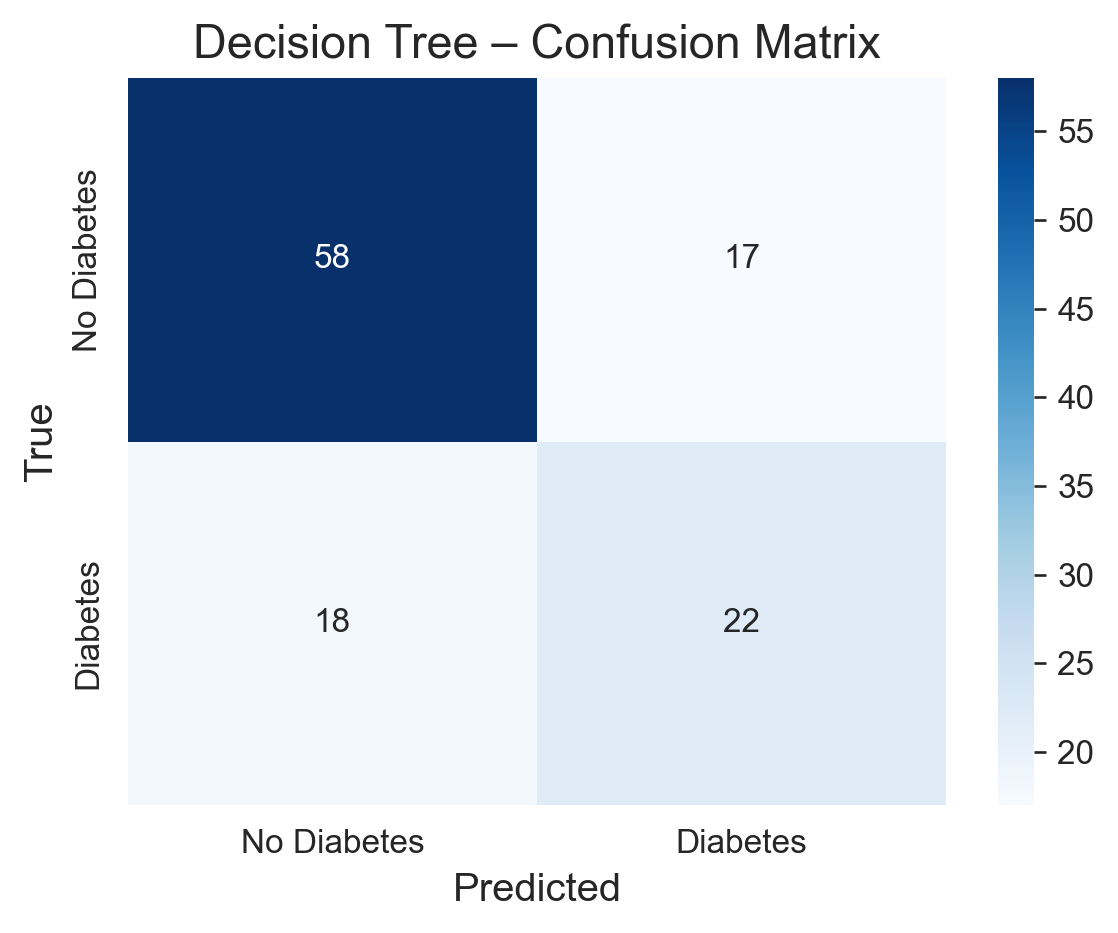


=== Random Forest ===
Test Accuracy: 0.7478
Test F1 (weighted): 0.7471

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81        75
           1       0.64      0.62      0.63        40

    accuracy                           0.75       115
   macro avg       0.72      0.72      0.72       115
weighted avg       0.75      0.75      0.75       115



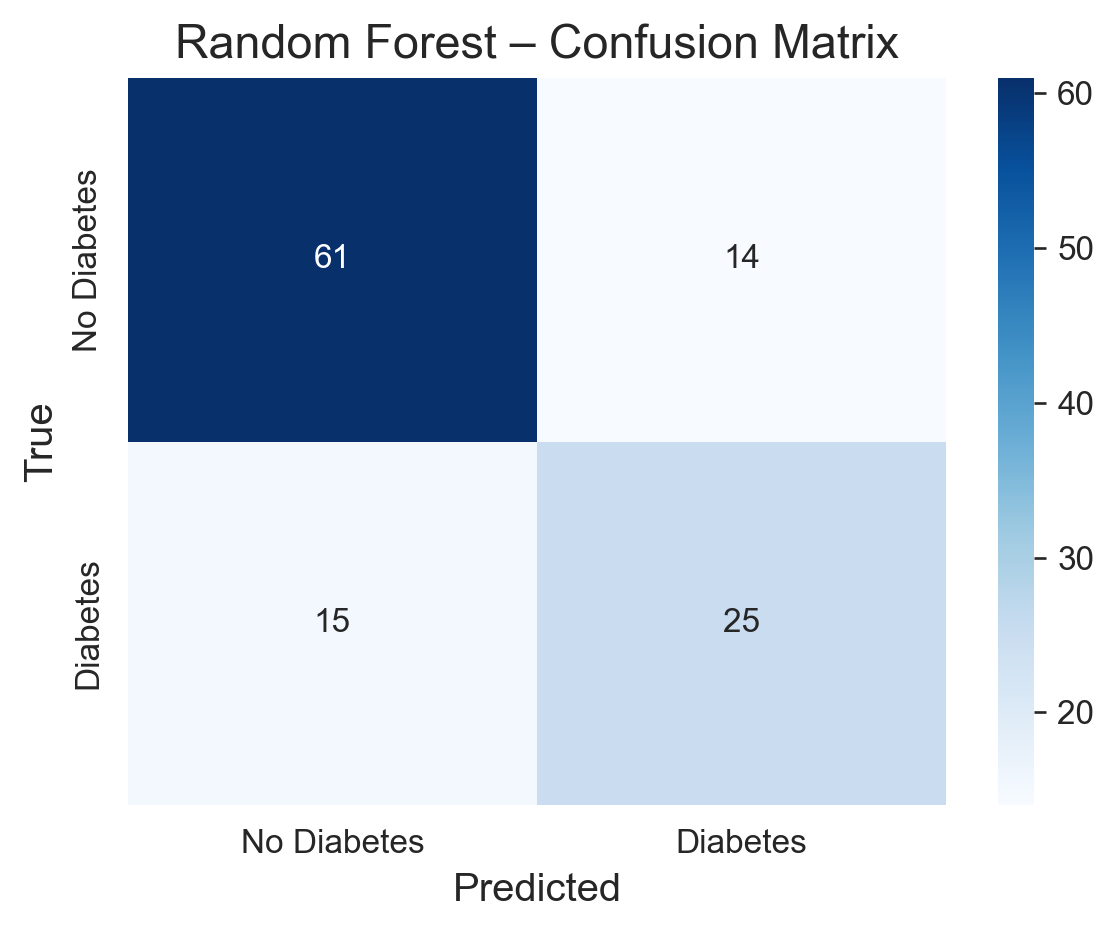


=== SVM ===
Test Accuracy: 0.7043
Test F1 (weighted): 0.7004

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78        75
           1       0.58      0.53      0.55        40

    accuracy                           0.70       115
   macro avg       0.67      0.66      0.67       115
weighted avg       0.70      0.70      0.70       115



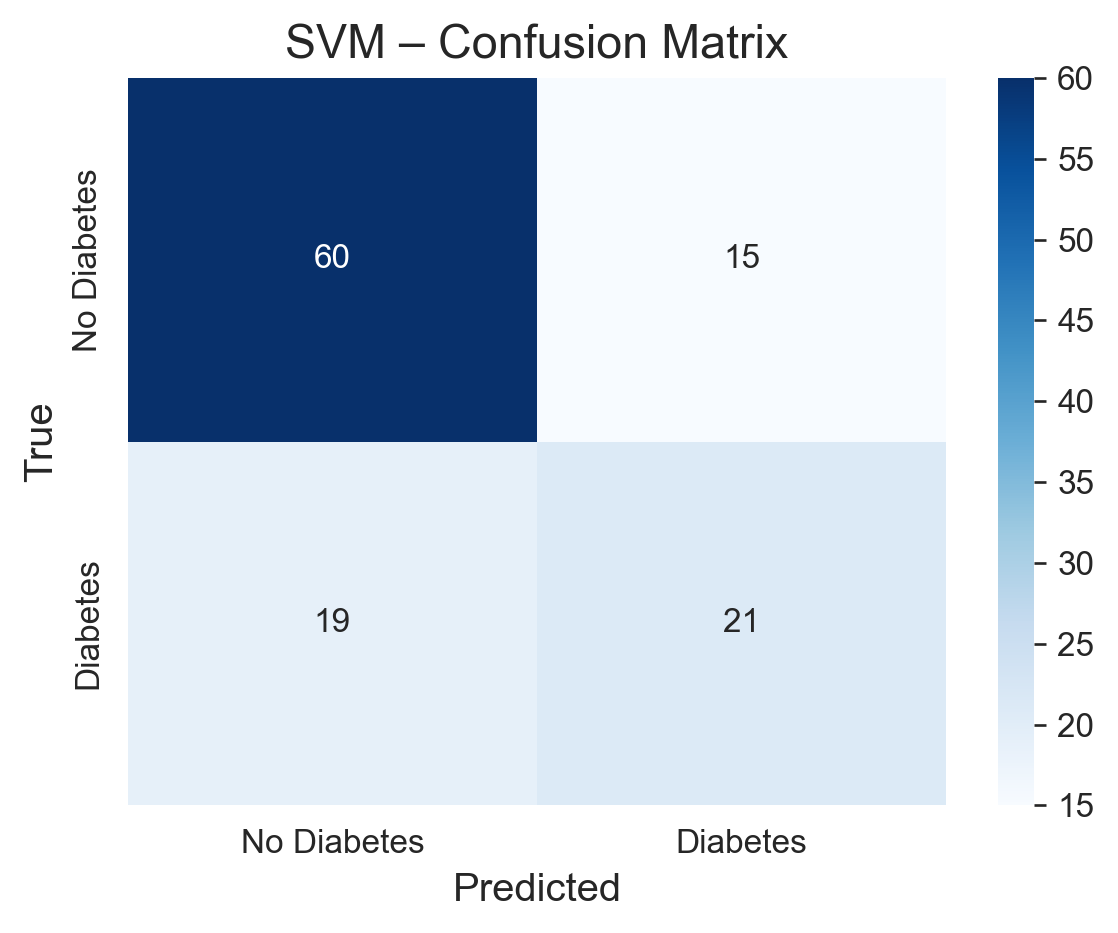


=== Validation Set Performance ===
              Model  Accuracy  Weighted F1
Logistic Regression  0.730435     0.725797
      Decision Tree  0.695652     0.694734
      Random Forest  0.747826     0.747065
                SVM  0.704348     0.700407


In [10]:
# %% Evaluation on Validation Set
results_val = []
for name, model in [
    ('Logistic Regression', best_lr),
    ('Decision Tree', best_dt),
    ('Random Forest', best_rf),
    ('SVM', best_svm)
]:
    acc, f1 = evaluate_model(model, X_val, y_val, name)
    results_val.append({'Model': name, 'Accuracy': acc, 'Weighted F1': f1})

df_results_val = pd.DataFrame(results_val)
print("\n=== Validation Set Performance ===")
print(df_results_val.to_string(index=False))

## 4. Final Evaluation on Test Set

We select the best performing model from validation and evaluate it on the held‑out test set.

Best model based on validation: Random Forest

=== Random Forest (Test) ===
Test Accuracy: 0.7414
Test F1 (weighted): 0.7288

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.88      0.81        75
           1       0.69      0.49      0.57        41

    accuracy                           0.74       116
   macro avg       0.72      0.68      0.69       116
weighted avg       0.73      0.74      0.73       116



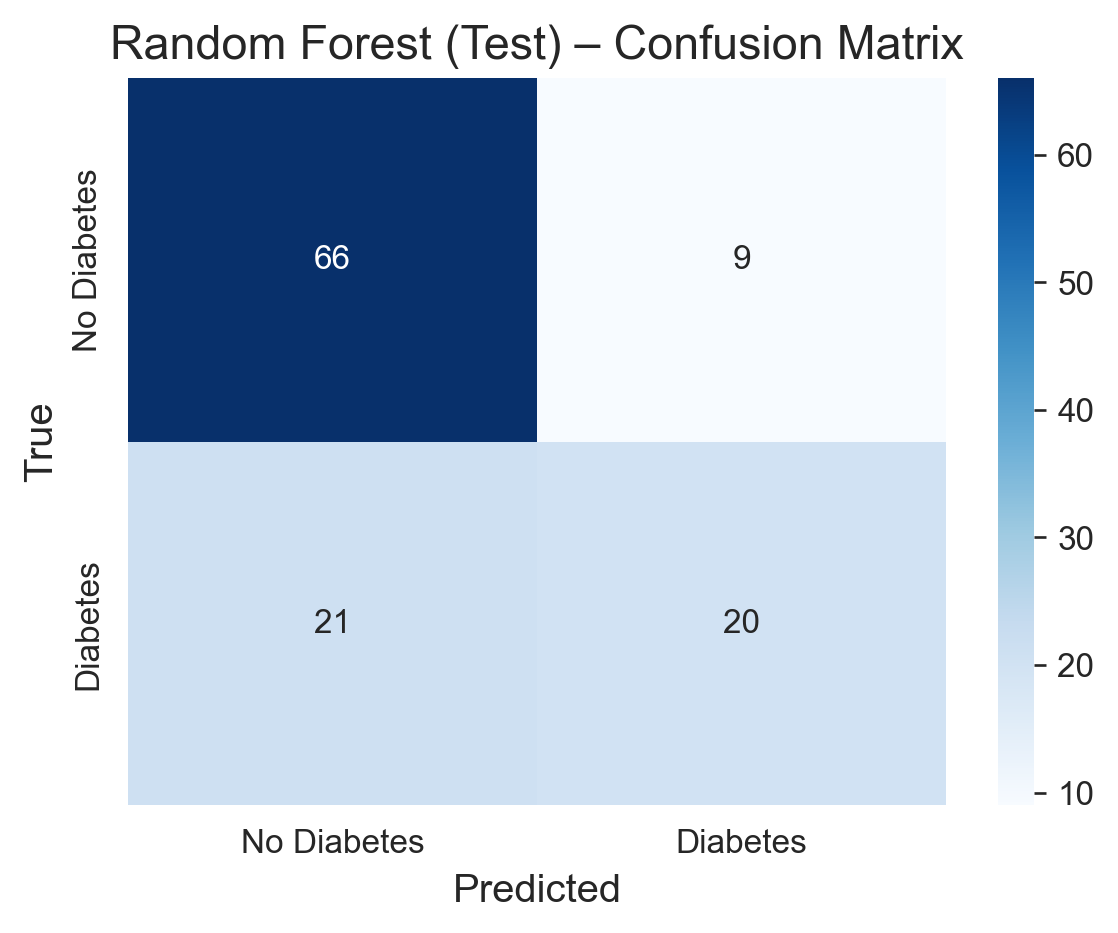

In [11]:
# %% Final Test Evaluation
# Choose best model based on validation accuracy
best_model_name = df_results_val.loc[df_results_val['Accuracy'].idxmax(), 'Model']
if best_model_name == 'Logistic Regression':
    final_model = best_lr
elif best_model_name == 'Decision Tree':
    final_model = best_dt
elif best_model_name == 'Random Forest':
    final_model = best_rf
else:
    final_model = best_svm

print(f"Best model based on validation: {best_model_name}")
acc_test, f1_test = evaluate_model(final_model, X_test, y_test, f"{best_model_name} (Test)")

## 5. Learning Curves

We plot learning curves to diagnose bias‑variance trade‑off for the final model.

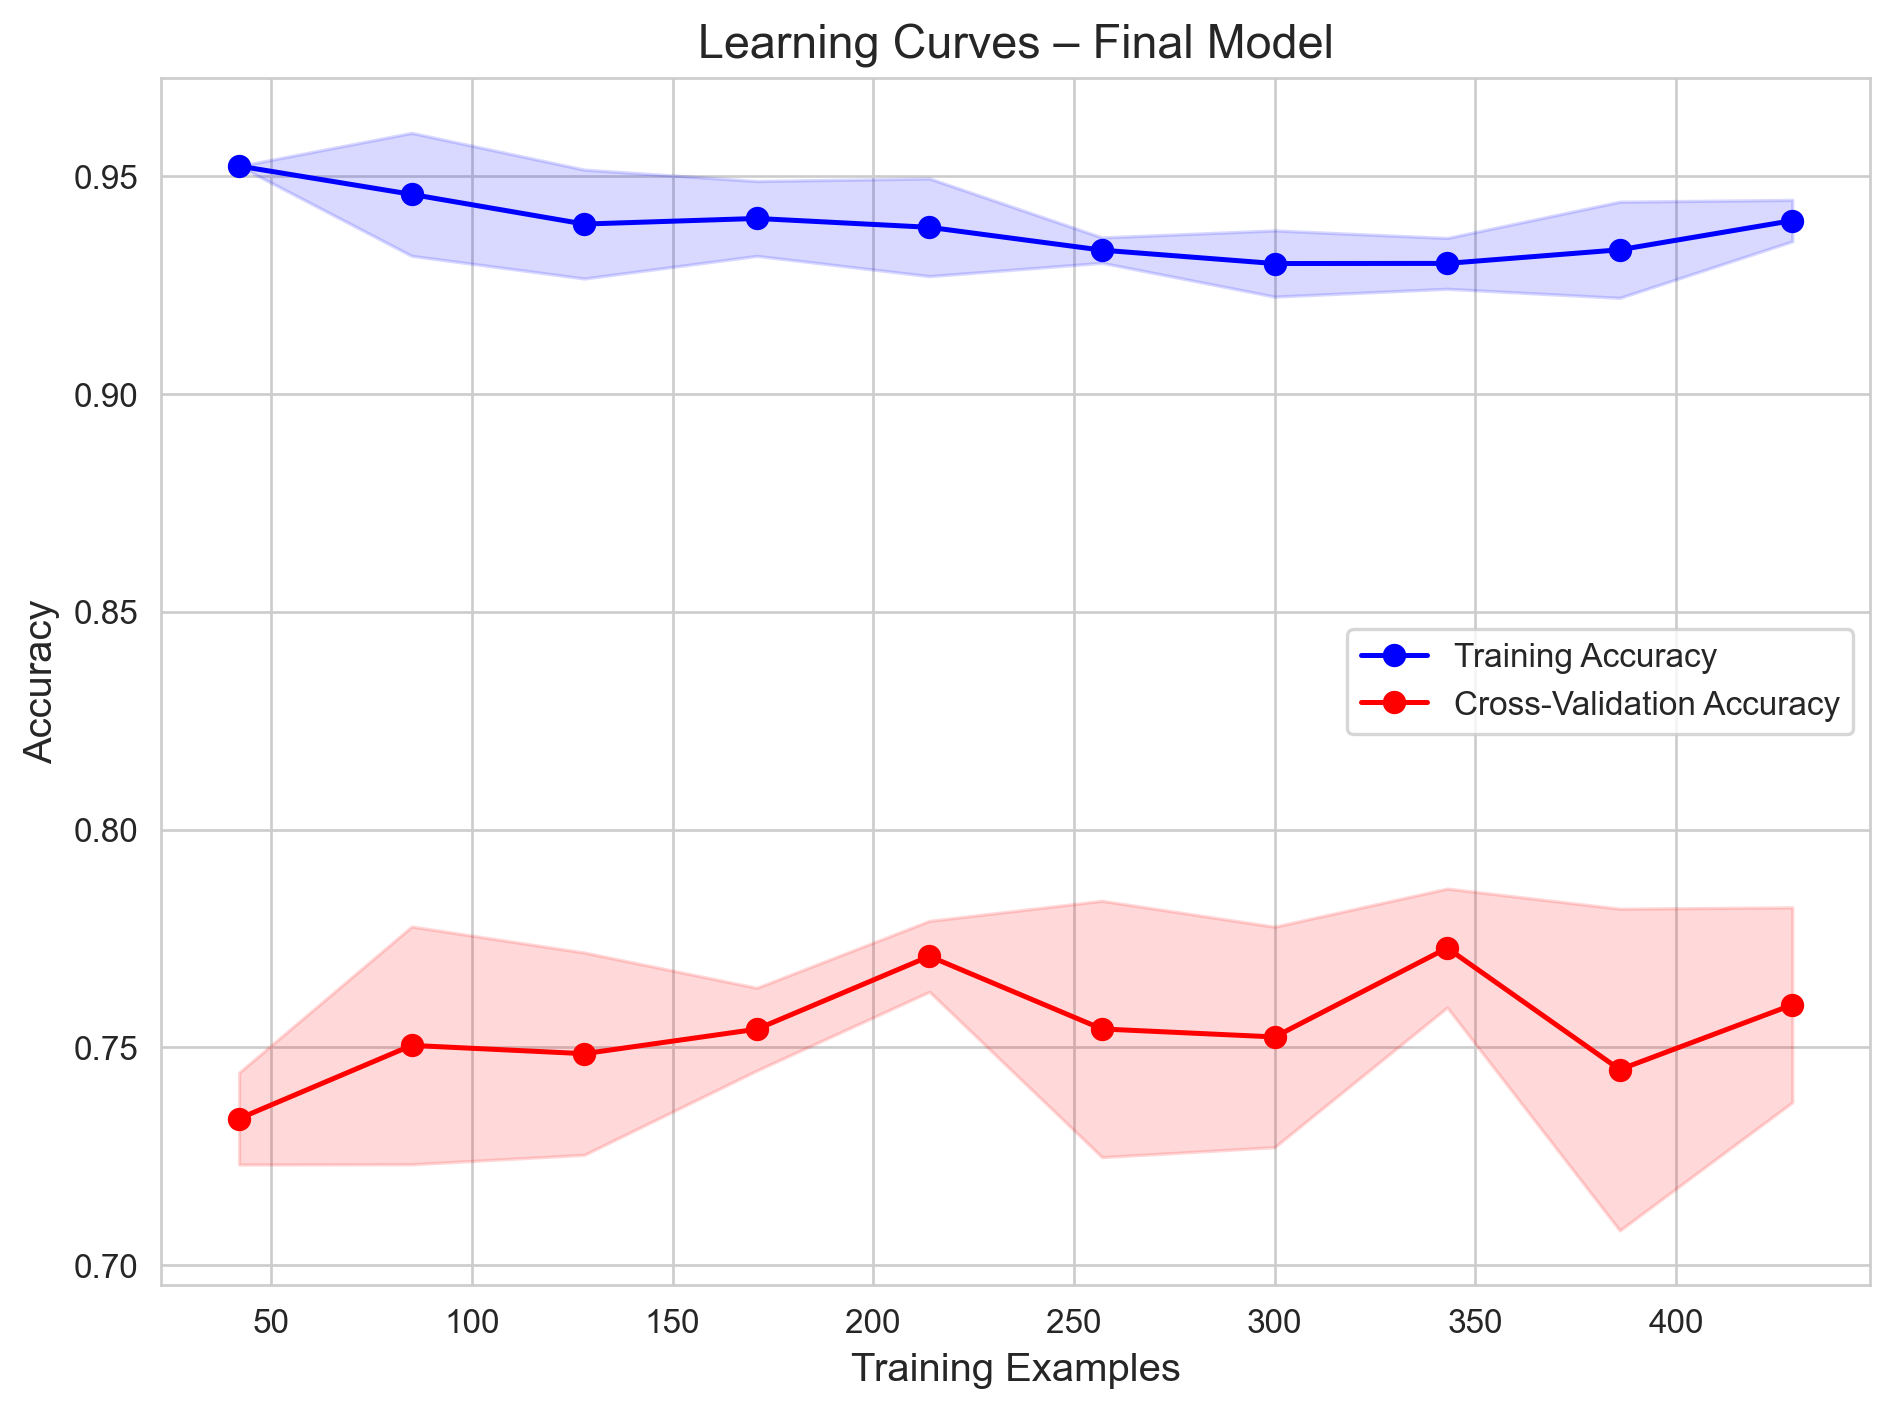

In [13]:
# %% Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, label='Cross-Validation Accuracy', color='red', marker='o')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curves – Final Model')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig('plots/learning_curve.png', dpi=300)
plt.show()

## Summary and Next Steps

**Accomplished:**
- Loaded and explored the Pima Indians Diabetes dataset (768 samples, 8 features, binary classification: 65.1% non‑diabetic, 34.9% diabetic).
- Conducted exploratory data analysis with correlation heatmaps and pair plots, revealing that **Glucose**, **BMI**, and **Age** are strongly associated with the outcome.
- Preprocessed data using `StandardScaler` and split into training (70%), validation (15%), and test (15%) sets.
- Evaluated four base models (Logistic Regression, Decision Tree, Random Forest, SVM) using 5‑fold cross‑validation on the training set:
  - **Logistic Regression**: 0.7858 (±0.0191)
  - **SVM**: 0.7524 (±0.0173)
  - **Random Forest**: 0.7450 (±0.0189)
  - **Decision Tree**: 0.6814 (±0.0361)
- Performed hyperparameter tuning for each model using **GridSearchCV**, optimising for accuracy.
- Evaluated tuned models on the validation set and selected the best performing model (**Random Forest**, 74.8% accuracy).
- Evaluated the final model on the held‑out test set:
  - **Accuracy**: 74.1%
  - **Weighted F1**: 0.7288
- Plotted learning curves for the final model to diagnose bias‑variance trade‑off.

**Key Results (Validation Set):**
| Model | Accuracy | Weighted F1 |
|-------|----------|-------------|
| Logistic Regression | 73.0% | 0.7258 |
| Decision Tree | 69.6% | 0.6947 |
| Random Forest | **74.8%** | **0.7471** |
| SVM | 70.4% | 0.7004 |

**Key Results (Test Set – Random Forest):**
| Metric | Value |
|--------|-------|
| Accuracy | 74.1% |
| Weighted F1 | 0.7288 |
| Precision (No Diabetes / Diabetes) | 0.76 / 0.69 |
| Recall (No Diabetes / Diabetes) | 0.88 / 0.49 |

**Key Insights:**
- **Random Forest** performed best on the validation set, likely due to its ability to capture non‑linear interactions and handle feature importance effectively.
- **Logistic Regression** was the second‑best model, demonstrating that a linear decision boundary is reasonably effective for this dataset.
- **Decision Tree** performed worst, likely due to overfitting; this was partially mitigated by tuning `max_depth` and `min_samples_split`.
- The **learning curve** shows a significant gap between training and cross‑validation accuracy, indicating **potential overfitting**. Adding more training data or applying stronger regularisation could improve generalisation.
- The model struggles to recall the minority class (Diabetes), with a recall of only 0.49 on the test set. This suggests that **class imbalance** is a significant challenge.

**Suggested Next Steps:**
1. **Address Class Imbalance:** Apply SMOTE (oversampling) or class weighting (`class_weight='balanced'`) to improve recall for the minority class.
2. **Feature Engineering:** Create interaction terms (e.g., `BMI * Glucose`) or polynomial features to capture non‑linear relationships.
3. **Feature Selection:** Use recursive feature elimination (RFE) or L1 regularisation to identify the most predictive features.
4. **Other Models:** Explore XGBoost, LightGBM, or neural networks, which often outperform traditional models on tabular data.
5. **Cross‑Validation:** Use stratified k‑fold cross‑validation with more folds (e.g., 10‑fold) for more robust performance estimates.
6. **Threshold Tuning:** Adjust the decision threshold to balance precision and recall based on the application (e.g., reducing false negatives for medical diagnosis).
7. **Deployment:** Save the best model and scaler to a file and create a simple REST API for real‑time predictions.
8. **Explainability:** Use SHAP or LIME to interpret model predictions, which is especially important in clinical applications.

**Final Reflection:**
This notebook provides a robust and reproducible model selection pipeline, suitable for a professional portfolio. The systematic approach – from baseline cross‑validation to hyperparameter tuning to final test evaluation – demonstrates a deep understanding of model selection and validation. The results highlight the importance of handling class imbalance and the value of ensemble methods for tabular classification problems. The learning curve analysis provides actionable insights for further improvement.